# Fase 2 — Post-filtro (barrido) y comparación con mono

Sobre el algoritmo ganador de la Fase 1 (**NM-MVDR**, sin WPE) se estudian las
variantes de **post-filtro** y se compara contra el **DTLN monocanal** (baseline
single-channel automático). Escenario acústicamente diverso; el foco es el barrido
**RT60 × SNR** para ver tendencias y **diseñar un post-filtro adaptativo** (más
agresivo a SNR bajo).

- **Beamformer único:** NM-MVDR (el de la Fase 1). No se comparan otros BF acá.
- **Post-filtros (PLACEHOLDER):** varias variantes/hiperparámetros; muchas **aún
  sin diseñar**. Acá van como barrido de `smooth` sobre `PF`/`BANPF`; agregá las
  nuevas a medida que se definan.
- **Baseline mono:** DTLN-mono sale automático si hay interpreters cargados.

*Salida:* elegir/diseñar el post-filtro óptimo con parámetros automáticos según el
entorno (RT/SNR).

**Correr en orden:** Setup → Config+Run → Análisis → Figuras.

## Setup — ejecutar una vez por sesión de Colab
Montar Drive, clonar el repo, instalar dependencias y actualizar el código.

In [1]:
# Import the drive module from Google Colab
from google.colab import drive

# Mount Google Drive to the virtual machine
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 3. Descargar tu código temporalmente
%cd /content
!git clone https://github.com/MatiasVereert/Vision-Aided-Beamformer.git

/content
fatal: destination path 'Vision-Aided-Beamformer' already exists and is not an empty directory.


In [3]:
import os, importlib, importlib.util

WHL = "/content/drive/MyDrive/colab_wheels"   # cache persistente de wheels en Drive
ip = get_ipython()

# (modulo que se importa, spec para instalar). git+ para las libs de GitHub;
# el resto por nombre. Mismos specs de siempre -> NO fuerza rebuild del cache.
PKGS = [
    ("noisereduce",     "noisereduce"),
    ("mir_eval",        "mir_eval"),
    ("pystoi",          "pystoi"),
    ("pesq",            "pesq"),
    ("paderbox",        "paderbox"),
    ("ai_edge_litert",  "ai_edge_litert"),
    ("pb_bss",          "git+https://github.com/fgnt/pb_bss.git"),
    ("pyroomacoustics", "git+https://github.com/LCAV/pyroomacoustics.git"),
    ("nara_wpe",        "git+https://github.com/fgnt/nara_wpe.git"),
    ("fast_bss_eval",   "git+https://github.com/fakufaku/fast_bss_eval.git"),
]
def _name(spec):  # nombre instalable desde el cache (sin git+/.git)
    return spec.rsplit("/", 1)[-1].replace(".git", "") if spec.startswith("git+") else spec
BUILD = [spec for _, spec in PKGS]

# 1) (Re)construir el cache de wheels en Drive SOLO si cambio la lista (manifest).
manifest = os.path.join(WHL, ".manifest.txt")
key = "\n".join(sorted(BUILD))
if (not os.path.isfile(manifest)) or open(manifest).read() != key:
    os.makedirs(WHL, exist_ok=True)
    print("[*] (Re)construyendo cache de wheels en Drive (una vez por cambio de lista)...")
    ip.system(f"pip wheel --wheel-dir={WHL} " + " ".join(BUILD))
    with open(manifest, "w") as fh:
        fh.write(key)

# 2) Instalar desde el cache PAQUETE POR PAQUETE. Si a uno le falta la wheel
#    (p.ej. Colab cambio de version de Python), NO bloquea a los demas.
for mod, spec in PKGS:
    if importlib.util.find_spec(mod) is None:
        ip.system(f"pip install --no-index --find-links={WHL} {_name(spec)}")

# 3) AUTOCURA: lo que SIGA sin poder importarse se instala desde el indice
#    (PyPI/git) y se agrega al cache para la proxima sesion. Esto arregla el
#    'ModuleNotFoundError: pyroomacoustics' cuando la wheel cacheada no sirve.
importlib.invalidate_caches()
missing = [(m, s) for m, s in PKGS if importlib.util.find_spec(m) is None]
if missing:
    print("[!] Faltan tras el cache:", [m for m, _ in missing], "-> instalando desde el indice...")
    ip.system("pip install " + " ".join(s for _, s in missing))
    ip.system(f"pip wheel --wheel-dir={WHL} " + " ".join(s for _, s in missing))
    importlib.invalidate_caches()

# 4) Verificacion final.
faltan = [m for m, _ in PKGS if importlib.util.find_spec(m) is None]
if faltan:
    print(f"[!] SIGUEN faltando {faltan}: reinicia el runtime "
          f"(Entorno de ejecucion > Reiniciar) y reejecuta esta celda.")
else:
    print("[*] Todas las dependencias OK.")
# Nuclear (si el cache quedo inservible tras un cambio de Python de Colab):
#   !rm -rf /content/drive/MyDrive/colab_wheels   y reejecuta -> reconstruye todo.

Looking in links: /content/drive/MyDrive/colab_wheels
Processing ./drive/MyDrive/colab_wheels/noisereduce-3.0.3-py3-none-any.whl
[*] Todas las dependencias OK.


In [4]:
%cd /content/Vision-Aided-Beamformer
!git pull origin main

/content/Vision-Aided-Beamformer
From https://github.com/MatiasVereert/Vision-Aided-Beamformer
 * branch            main       -> FETCH_HEAD
Already up to date.


## Config + Ejecución (Fase 2)

In [5]:
import sys, os, numpy as np, shutil
from datetime import datetime

repo_root = '/content/Vision-Aided-Beamformer'
src_path = os.path.join(repo_root, 'src')
for p in (repo_root, src_path):
    if p not in sys.path: sys.path.append(p)
%cd {src_path}

try:
    import tensorflow as tf
    TFLITE_AVAILABLE = True
except ImportError:
    TFLITE_AVAILABLE = False

from evaluation.full_benchmark_test_dtln_mird import run_mird_grid_search
from evaluation.bf_wrappers import (NM_MVDR, DTLN_MB_MVDR_SOUDEN_BAN,
                                    NM_MVDR_PF, NM_MVDR_BAN_PF)
from propagation.mird_loader import MirdDatasetProvider

m1 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_1.tflite")
m2 = os.path.join(repo_root, "src/dnn_denoise/models/model_quant_2.tflite")
interpreter_1 = interpreter_2 = None
if TFLITE_AVAILABLE and os.path.exists(m1) and os.path.exists(m2):
    interpreter_1 = tf.lite.Interpreter(model_path=m1); interpreter_1.allocate_tensors()
    interpreter_2 = tf.lite.Interpreter(model_path=m2); interpreter_2.allocate_tensors()
    print("[*] DTLN TFLite OK.")
else:
    print("[!] Sin DTLN interpreters.")

input_dir = "/content/drive/MyDrive/Benchmarks_tesis/inputs"
mird_dir  = "/content/drive/MyDrive/Benchmarks_tesis/rirs"
provider = MirdDatasetProvider(root_dir=mird_dir)

# ===================== PERILLAS =====================
DURATION = 15
SMOOTHS  = [0.2, 0.5,  0.8]   # <<< PLACEHOLDER: hiperparámetros del post-filtro
LOADINGS = [ 1e-6]  # <<< barrido de min_loading (carga diagonal), 1e-2 .. 1e-9
# ===================================================

TARGETS = [os.path.join(input_dir, f) for f in [
    "p002_emo_adoration_sentences.wav",
    "p008_emo_contentment_sentences.wav",
]]
INTERF = [os.path.join(input_dir, f) for f in [
    "techno_gated commune.wav", "hairdryer_07_SH_MKH800.wav", "drill_07_RHODE_NT1.wav",
]]
# Estrés espacial FIJO (no es el foco): 1 interferente y 3 simultáneos.
INTERF_CONFIGS = [
    [(45, 1.0, 0)],
    [(45, 1.0, 0), (-30, 1.0, 1), (60, 1.0, 2)],
]

base_config = {
    'fs': 16000, 'duration': DURATION, 't_early': 0.050,
    'array_center': [3.0, 3.0, 1.2], 'mird_spacing': "3-3-3-8-3-3-3",
    'snr_db': 60.0,
    'source_path': TARGETS[0], 'interf_paths': INTERF,
    # --- WPE ELIMINADO DEL SISTEMA (use_wpe=False en toda grilla). Estos escalares
    #     solo existen porque el benchmark los exige en scene_base_config; no operan.
    'wpe_taps': 5, 'wpe_delay': 2, 'wpe_alpha': 0.9999,
    'wpe_stft_size': 512, 'wpe_stft_shift': 128,
    'stft_window': 512, 'stft_overlap': 384,
    'dtln_model_path': m1,
    'eval_references': ['early'],
}

# --- GRILLA: barrido comprensivo RT60 x SNR (ejes primarios) ---
param_grid = {
    'rt60':           [0.160, 0.360, 0.610],
    'isir_db':        [-5, 0, 5, 10],     # denso: ver la tendencia por SNR
    'target_angle':   [0], 'target_dist': [1.0],
    'source_path':    TARGETS,
    'interf_configs': INTERF_CONFIGS,
    'use_wpe':        [False],
    'mismatch_gain':  [0], 'mismatch_phase': [0],
    'error_angle_deg':[0.0], 'error_distance_m':[0.0],
}

# --- PROCESADORES (Fase 2: SOLO NM-MVDR + variantes de post-filtro) ---
# BARRIDO de min_loading (carga diagonal del core) x smooth (post-filtro). Todas
# comparten el MISMO beamformer (NM-MVDR); cambian carga y post-filtro. El tag L#
# en el nombre = min_loading. DTLN-mono sale automático.
def _Ltag(L):  # etiqueta compacta y legible (p.ej. 1e-06) para el nombre del proc
    return f"L{L:.0e}"

processors_dict = {}
for L in LOADINGS:
    processors_dict[f"NM-MVDR_{_Ltag(L)}"] = NM_MVDR(min_loading=L, alpha=0.99)              # base
    processors_dict[f"BAN_{_Ltag(L)}"]     = DTLN_MB_MVDR_SOUDEN_BAN(min_loading=L)          # BAN
    for s in SMOOTHS:
        processors_dict[f"PF_{s}_{_Ltag(L)}"]    = NM_MVDR_PF(min_loading=L, alpha=0.99, smooth=s)
        processors_dict[f"BANPF_{s}_{_Ltag(L)}"] = NM_MVDR_BAN_PF(min_loading=L, alpha=0.99, smooth=s)
# TODO: agregar acá las variantes NUEVAS de post-filtro a medida que se diseñen.

n_cells = 3*len(TARGETS)*len(INTERF_CONFIGS)*len(param_grid['isir_db'])
print("="*60)
print(f"FASE 2 | celdas={n_cells} x {len(processors_dict)} proc")
print("procesadores:", list(processors_dict.keys()))
print("="*60)

import json
# RUN_ID con SEGUNDOS (sin colisiones); results_fases/ separa de los viejos Prueba_*.
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
temp_dir  = f"/content/results_temp/F2_{RUN_ID}"
drive_dir = f"/content/drive/MyDrive/Tesis_Beamformers/results_fases/F2_{RUN_ID}"
os.makedirs(temp_dir, exist_ok=True); os.makedirs(drive_dir, exist_ok=True)

df_F2 = run_mird_grid_search(
    grid_params=param_grid, dataset_provider=provider, processors=processors_dict,
    scene_base_config=base_config, output_dir=temp_dir,
    interpreter_1=interpreter_1, interpreter_2=interpreter_2,
    save_catalog=False, apply_dtln_post=True)

# DONE.json = marca de COMPLETITUD (solo si termino OK).
_np = len(processors_dict)
json.dump({"run_id": RUN_ID, "phase": "F2", "experiment": "postfiltro",
           "status": "COMPLETE", "rows": int(len(df_F2)), "n_processors": _np,
           "n_cells": int(len(df_F2) // max(_np, 1)),
           "processors": list(processors_dict.keys()),
           "grid": {k: str(v) for k, v in param_grid.items()},
           "finished_utc": datetime.utcnow().isoformat() + "Z"},
          open(os.path.join(temp_dir, "DONE.json"), "w"), indent=2, ensure_ascii=False)
shutil.copytree(temp_dir, drive_dir, dirs_exist_ok=True)
print(f"[EXITO] Fase 2 -> {drive_dir}  ({len(df_F2)} filas, {_np} proc)")

/content/Vision-Aided-Beamformer/src


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[*] DTLN TFLite OK.
[MirdDatasetProvider] Successfully indexed 234 RIR files from: /content/drive/MyDrive/Benchmarks_tesis/rirs
FASE 2 | celdas=48 x 8 proc
procesadores: ['NM-MVDR_L1e-06', 'BAN_L1e-06', 'PF_0.2_L1e-06', 'BANPF_0.2_L1e-06', 'PF_0.5_L1e-06', 'BANPF_0.5_L1e-06', 'PF_0.8_L1e-06', 'BANPF_0.8_L1e-06']
[*] t_early FIXED at 50.0 ms (decoupled from wpe_delay).
[*] Total experiments to run: 48 per processor (8 processors -> 384 rows).


MIRD Benchmark   0%|          | 0/48 exp [00:00<?, ?exp/s]

   0%|          | 0/1

/content/Vision-Aided-Beamformer/src/utils/audio.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_file, data = wavfile.read(filename)
 [*] [REF-MIC] canal 4 de 8 (metricas + proyeccion de TODOS los beamformers).
/usr/local/lib/python3.13/dist-packages/fast_bss_eval/numpy/helpers.py:69: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(ratio)




=== BATCH COMPLETED IN 60.56 MINUTES ===
[EXITO] Fase 2 -> /content/drive/MyDrive/Tesis_Beamformers/results_fases/F2_20260829_025346  (384 filas, 8 proc)


/tmp/ipykernel_2680/3978382315.py:122: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "finished_utc": datetime.utcnow().isoformat() + "Z"},


### Preview rápido (en memoria)

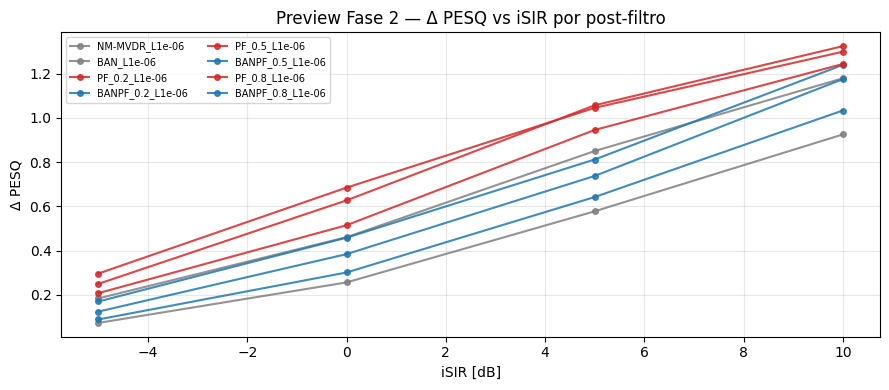

In [6]:
# Δ PESQ vs iSIR por post-filtro (tendencia para el diseño adaptativo). Usa df_F2.
import matplotlib.pyplot as plt
def _famc(n):
    return "tab:blue" if n.startswith("BANPF") else ("tab:red" if n.startswith("PF_") else "gray")
fig, ax = plt.subplots(figsize=(9, 4))
for name in df_F2.processor.unique():
    g = df_F2[df_F2.processor == name].groupby("isir_db")["Delta_tot_PESQ_early"].mean()
    ax.plot(g.index.values, g.values, "-o", ms=4, color=_famc(name), alpha=0.85, label=name)
ax.set_xlabel("iSIR [dB]"); ax.set_ylabel("Δ PESQ"); ax.grid(alpha=0.3)
ax.legend(fontsize=7, ncol=2); ax.set_title("Preview Fase 2 — Δ PESQ vs iSIR por post-filtro")
plt.tight_layout(); plt.show()

## Análisis — trade-off del post-filtro y tendencias RT/SNR

In [7]:
import pandas as pd, numpy as np
df = pd.read_csv(os.path.join(drive_dir, "mird_benchmark_metrics.csv"))

MET  = [("Delta_tot_PESQ_early","PESQ"), ("Delta_tot_STOI_early","STOI"),
        ("Delta_tot_SDR_early","SDR"), ("Delta_tot_SIR_early","SIR"),
        ("Delta_tot_SAR_early","SAR")]
cols = [c for c,_ in MET if c in df.columns]

print("=== Δ end-to-end (media sobre escenas) por procesador -> trade-off ===\n")
tab = df.groupby("processor")[cols].mean().rename(columns=dict(MET)).round(3)
print(tab.sort_values("PESQ", ascending=False).to_string())

# tendencia por SNR: qué post-filtro gana a cada iSIR (para el diseño adaptativo)
print("\n=== Δ PESQ medio por (procesador x iSIR) -> ¿más agresivo a SNR bajo? ===")
piv = df.pivot_table(index="processor", columns="isir_db",
                     values="Delta_tot_PESQ_early", aggfunc="mean").round(3)
print(piv.to_string())

=== Δ end-to-end (media sobre escenas) por procesador -> trade-off ===

                   PESQ   STOI    SDR     SIR     SAR
processor                                            
PF_0.2_L1e-06     0.832  0.125  6.742  18.143 -19.229
PF_0.5_L1e-06     0.815  0.142  7.049  16.753 -18.656
PF_0.8_L1e-06     0.728  0.148  7.047  15.238 -18.307
BANPF_0.2_L1e-06  0.670  0.130  6.692  14.004 -18.264
NM-MVDR_L1e-06    0.669  0.149  6.979  14.413 -18.186
BANPF_0.5_L1e-06  0.606  0.145  6.322  11.596 -17.777
BANPF_0.8_L1e-06  0.517  0.149  5.854  10.273 -17.702
BAN_L1e-06        0.458  0.149  5.489   9.555 -17.797

=== Δ PESQ medio por (procesador x iSIR) -> ¿más agresivo a SNR bajo? ===
isir_db             -5      0      5      10
processor                                   
BANPF_0.2_L1e-06  0.170  0.459  0.812  1.240
BANPF_0.5_L1e-06  0.124  0.384  0.738  1.176
BANPF_0.8_L1e-06  0.089  0.301  0.643  1.034
BAN_L1e-06        0.073  0.256  0.578  0.926
NM-MVDR_L1e-06    0.184  0.461  0.851  1.18

## Figuras — trade-off y tendencia por SNR/RT (diseño adaptativo)

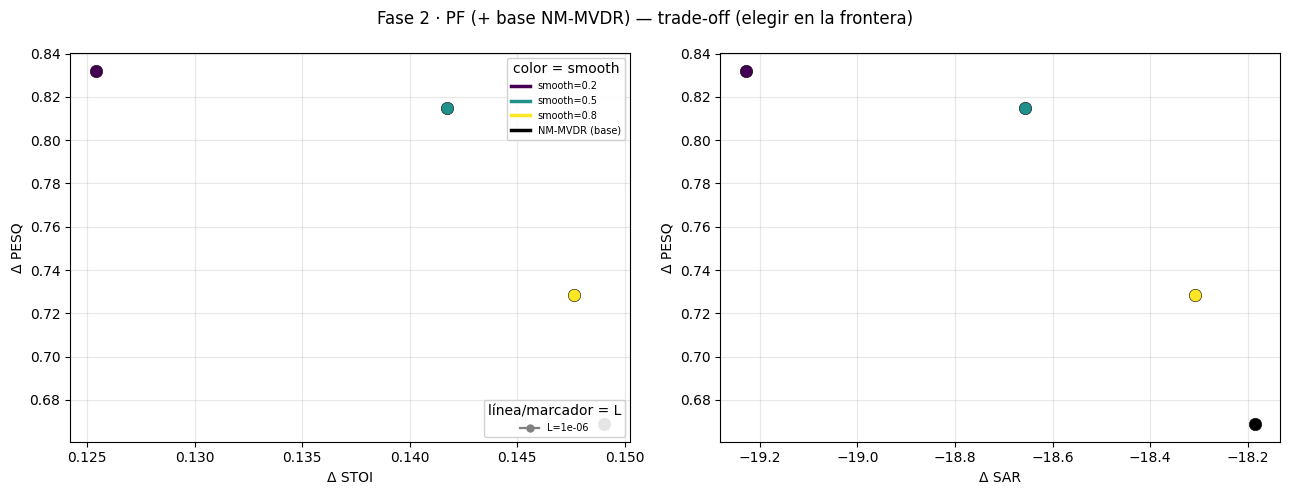

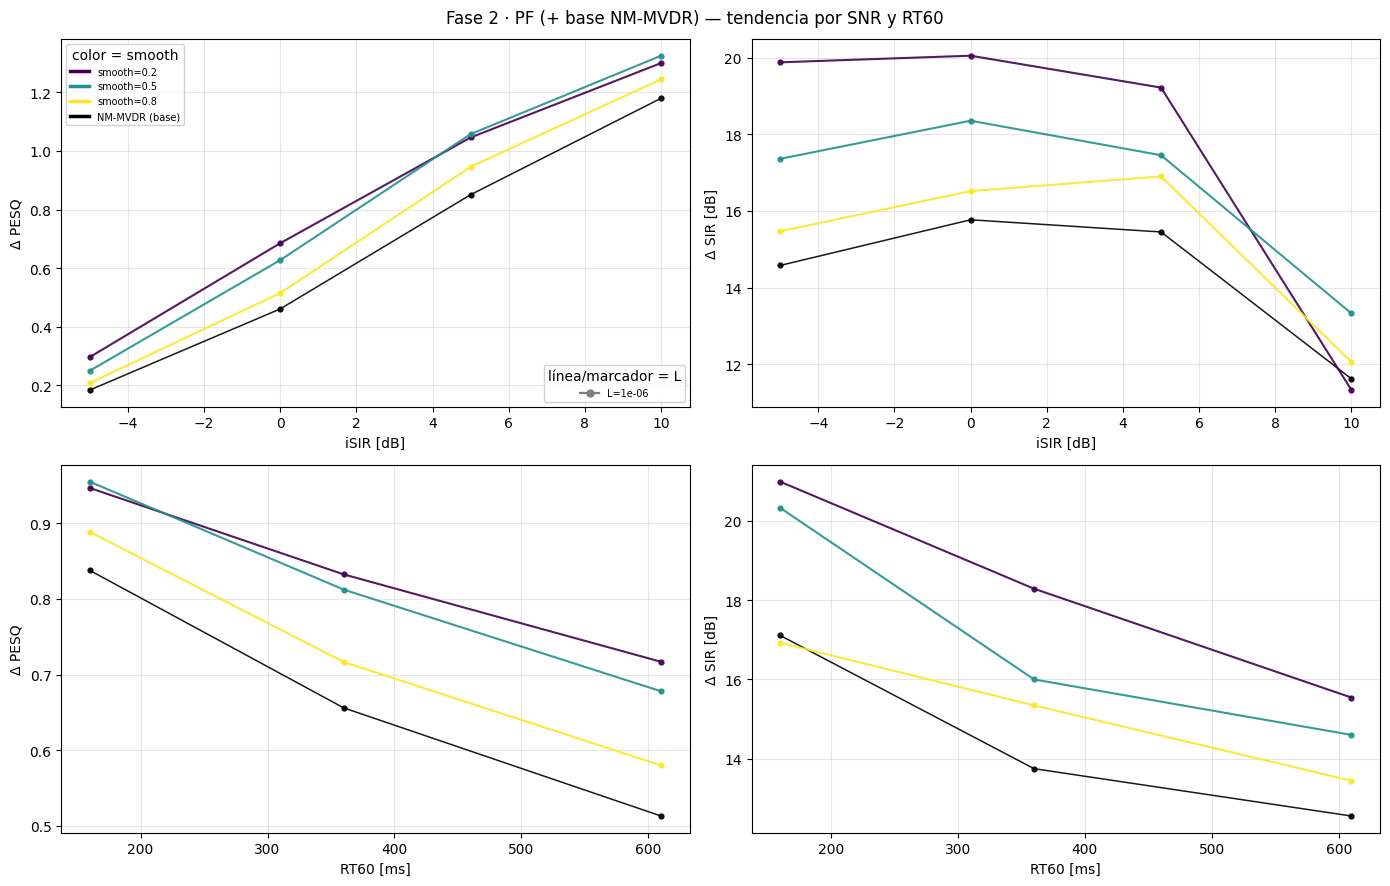

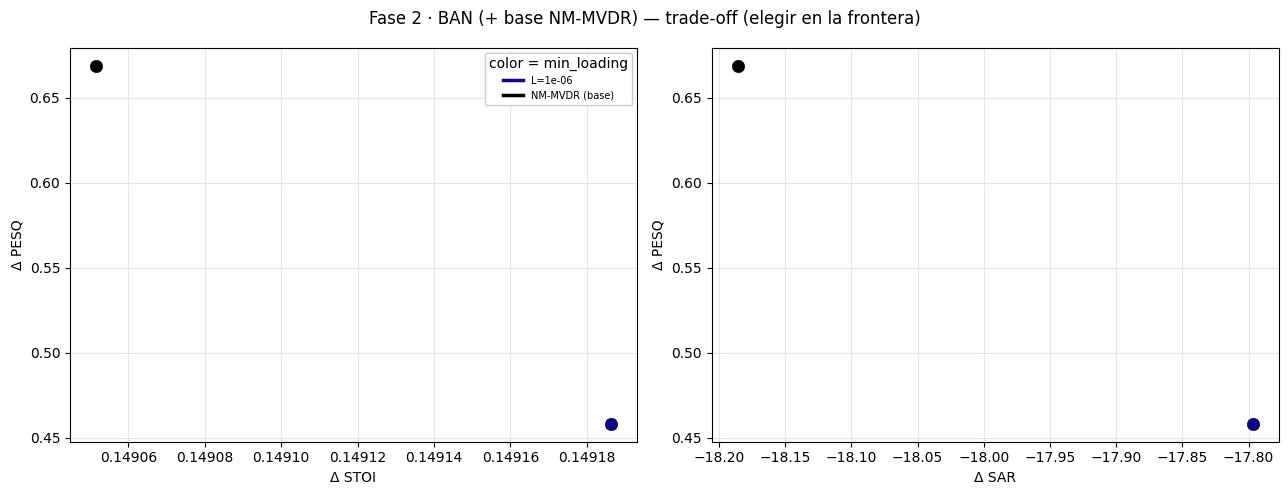

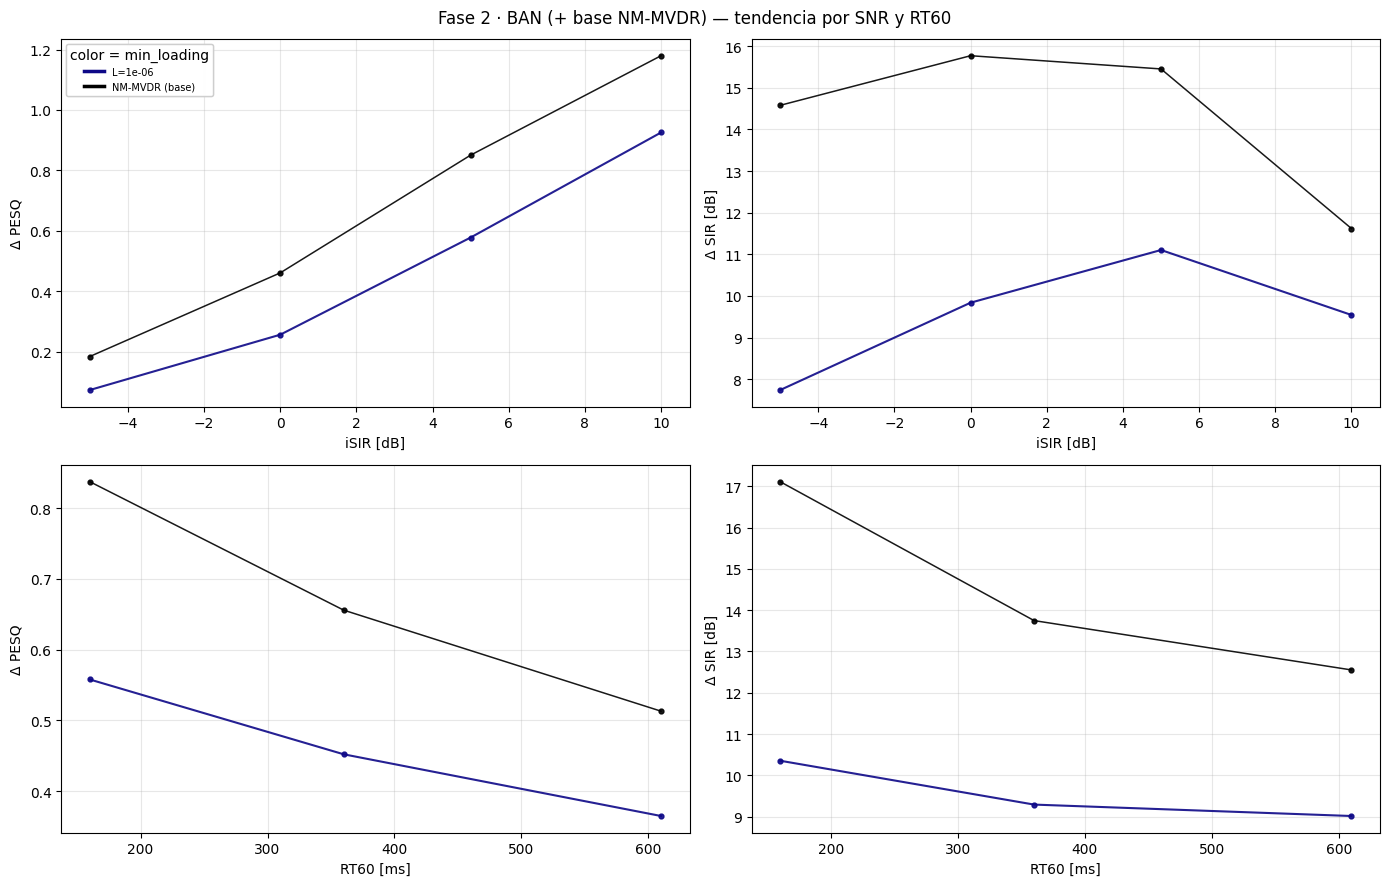

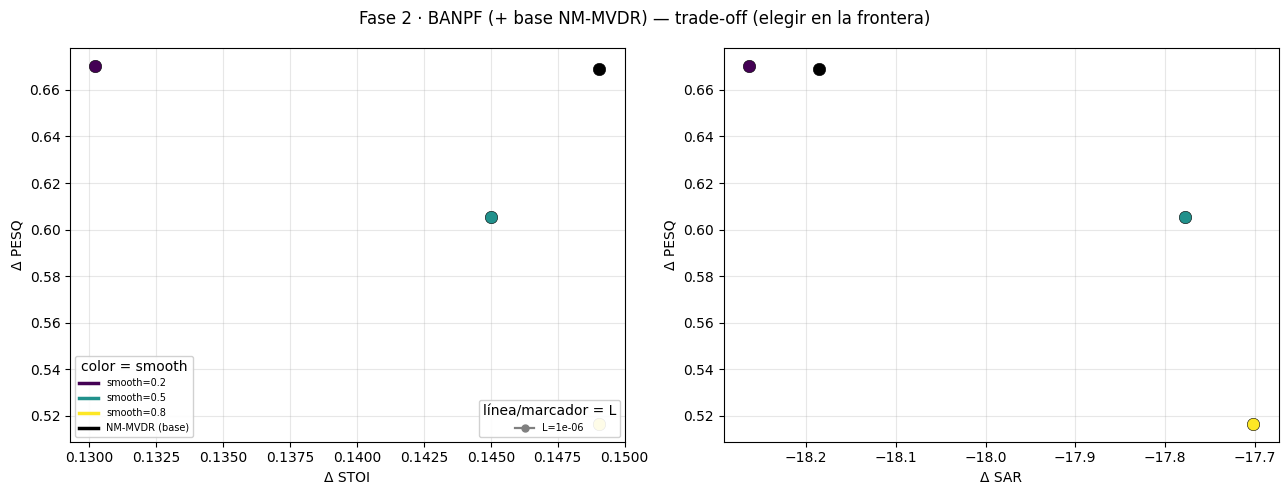

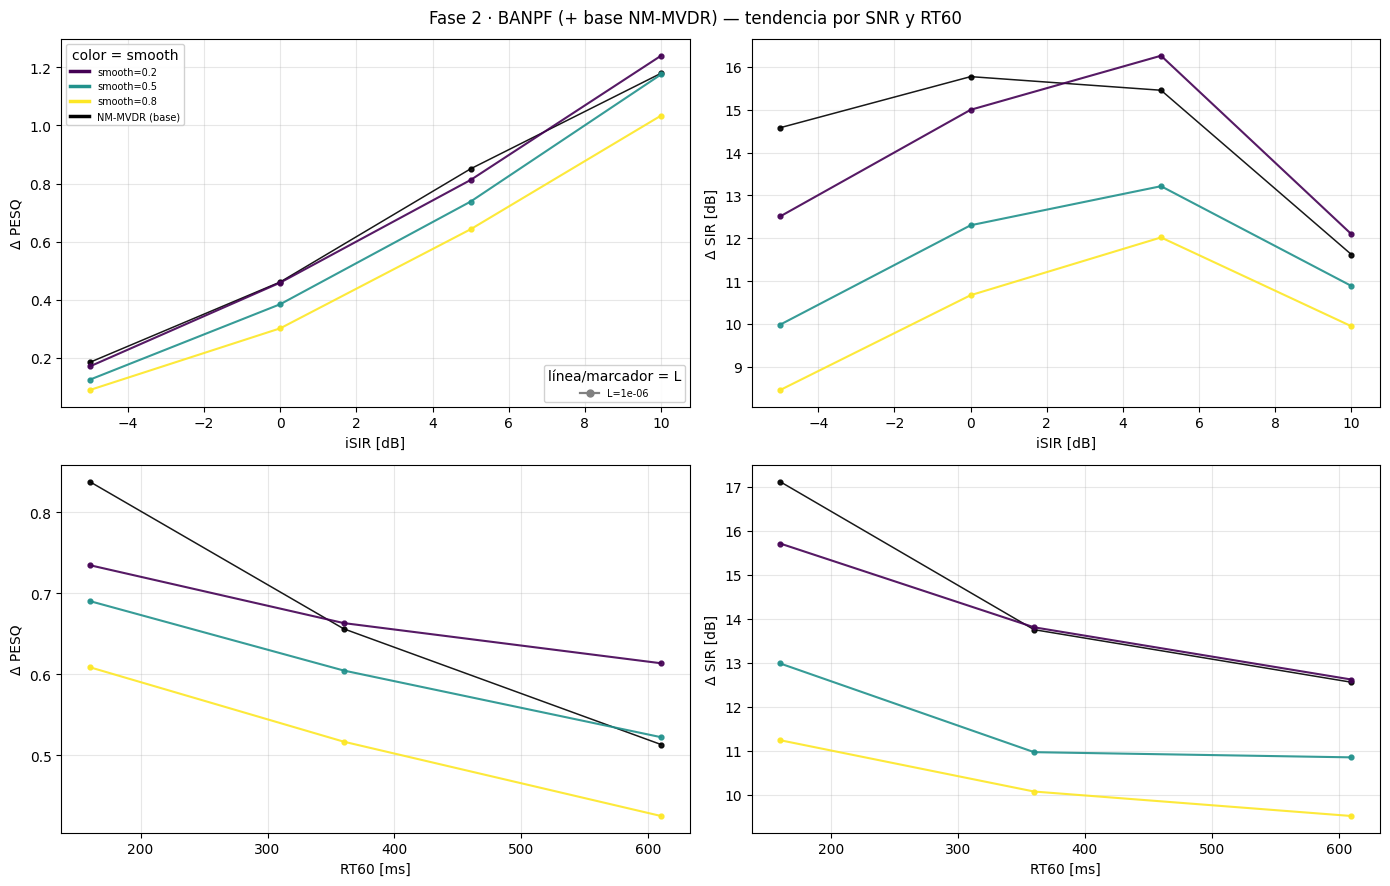

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

df = pd.read_csv(os.path.join(drive_dir, "mird_benchmark_metrics.csv"))

MET  = [("Delta_tot_PESQ_early","PESQ"), ("Delta_tot_STOI_early","STOI"),
        ("Delta_tot_SDR_early","SDR"), ("Delta_tot_SIR_early","SIR"),
        ("Delta_tot_SAR_early","SAR")]
cols = [c for c,_ in MET if c in df.columns]
agg  = df.groupby("processor")[cols].mean()

# --- Parseo del nombre del procesador -> (familia, smooth, min_loading) ---
# Nombres: NM-MVDR_L1e-06 | BAN_L1e-06 | PF_0.33_L1e-06 | BANPF_0.5_L1e-09
def parse_proc(name):
    m = re.match(r"(NM-MVDR|BANPF|BAN|PF)(?:_([0-9.]+))?_L(\S+)$", name)
    if not m: return None
    fam, s, L = m.group(1), m.group(2), m.group(3)
    return fam, (float(s) if s is not None else None), L

parsed  = {p: parse_proc(p) for p in df.processor.unique()}
parsed  = {p: v for p, v in parsed.items() if v is not None}
smooths = sorted({v[1] for v in parsed.values() if v[1] is not None})
loads   = sorted({v[2] for v in parsed.values()}, key=lambda x: float(x), reverse=True)  # 1e-2 -> 1e-9

# CODIFICACION VISUAL:
#   PF / BANPF: color = smooth ; linea+marcador = min_loading.
#   BAN (sin smooth): color = min_loading.
#   NM-MVDR (base): negro ; linea+marcador = min_loading (siempre superpuesto).
SCOL  = {s: plt.cm.viridis(i/max(1, len(smooths)-1)) for i, s in enumerate(smooths)}
LCOL  = {L: plt.cm.plasma(i/max(1, len(loads)-1))   for i, L in enumerate(loads)}
_LSTY = ["-", "--", "-.", ":"]
_LMRK = ["o", "s", "^", "D", "v", "P"]
LLS   = {L: _LSTY[i % len(_LSTY)] for i, L in enumerate(loads)}
LMK   = {L: _LMRK[i % len(_LMRK)] for i, L in enumerate(loads)}

POST_FAMILIES = ["PF", "BAN", "BANPF"]        # una figura por familia, siempre con la base
def _has_smooth(fam): return fam in ("PF", "BANPF")

def _color(p, fam):
    f, s, L = parsed[p]
    if f == "NM-MVDR": return "black"
    return SCOL[s] if _has_smooth(fam) else LCOL[L]

def _dual_legend(ax, fam):
    if _has_smooth(fam):
        col_h = [Line2D([0],[0], color=SCOL[s], lw=2.5, label=f"smooth={s}") for s in smooths]
        col_title = "color = smooth"
    else:
        col_h = [Line2D([0],[0], color=LCOL[L], lw=2.5, label=f"L={L}") for L in loads]
        col_title = "color = min_loading"
    col_h += [Line2D([0],[0], color="black", lw=2.5, label="NM-MVDR (base)")]
    leg1 = ax.legend(handles=col_h, fontsize=7, loc="best", title=col_title, framealpha=0.9)
    ax.add_artist(leg1)
    if _has_smooth(fam):   # para PF/BANPF el estilo codifica el loading (2da leyenda)
        sty_h = [Line2D([0],[0], color="gray", lw=1.6, ls=LLS[L], marker=LMK[L], ms=5,
                        label=f"L={L}") for L in loads]
        ax.legend(handles=sty_h, fontsize=7, loc="lower right", title="línea/marcador = L",
                  framealpha=0.9)

# ---------- FIG por familia: TRADE-OFF (Δ PESQ vs Δ STOI / Δ SAR) ----------
def tradeoff_fig(fam):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, xcol, xlab in [(axes[0], "Delta_tot_STOI_early", "Δ STOI"),
                           (axes[1], "Delta_tot_SAR_early", "Δ SAR")]:
        if xcol not in agg.columns: continue
        for p, (f, s, L) in parsed.items():
            if f not in (fam, "NM-MVDR"): continue
            ax.scatter(agg.loc[p, xcol], agg.loc[p, "Delta_tot_PESQ_early"],
                       c=[_color(p, fam)], marker=LMK[L], s=80,
                       edgecolor="k", linewidth=0.4, zorder=3)
        ax.set_xlabel(xlab); ax.set_ylabel("Δ PESQ"); ax.grid(alpha=0.3)
    _dual_legend(axes[0], fam)
    fig.suptitle(f"Fase 2 · {fam} (+ base NM-MVDR) — trade-off (elegir en la frontera)")
    fig.tight_layout(); fig.savefig(os.path.join(drive_dir, f"F2_{fam}_tradeoff.png"),
                                    dpi=140, bbox_inches="tight"); plt.show()

# ---------- FIG por familia: TENDENCIA vs iSIR y vs RT60 ----------
def trend_fig(fam):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    specs = [(axes[0][0], "isir_db", "iSIR [dB]", 1.0,   "Delta_tot_PESQ_early", "Δ PESQ"),
             (axes[0][1], "isir_db", "iSIR [dB]", 1.0,   "Delta_tot_SIR_early",  "Δ SIR [dB]"),
             (axes[1][0], "rt60",    "RT60 [ms]", 1000., "Delta_tot_PESQ_early", "Δ PESQ"),
             (axes[1][1], "rt60",    "RT60 [ms]", 1000., "Delta_tot_SIR_early",  "Δ SIR [dB]")]
    for ax, xcol, xlab, xsc, ycol, ylab in specs:
        for p, (f, s, L) in parsed.items():
            if f not in (fam, "NM-MVDR"): continue
            g = df[df.processor == p].groupby(xcol)[ycol].mean()
            ax.plot(g.index.values*xsc, g.values, color=_color(p, fam),
                    ls=LLS[L], marker=LMK[L], ms=3.5,
                    lw=(1.1 if f == "NM-MVDR" else 1.5), alpha=0.9)
        ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.grid(alpha=0.3)
    _dual_legend(axes[0][0], fam)
    fig.suptitle(f"Fase 2 · {fam} (+ base NM-MVDR) — tendencia por SNR y RT60")
    fig.tight_layout(); fig.savefig(os.path.join(drive_dir, f"F2_{fam}_trend.png"),
                                    dpi=140, bbox_inches="tight"); plt.show()

for _fam in POST_FAMILIES:
    tradeoff_fig(_fam)
    trend_fig(_fam)